### 1. Data Initialization

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import matplotlib.dates as mdates
# ---------------------------------------------------------------------------
# Caminhos
# ---------------------------------------------------------------------------
BASE_DIR = Path(r"C:\myenv\env\Mestrado\2026_imdc_challenge")

DB_DIR  = BASE_DIR / "0_databases"




# ---------------------------------------------------------------------------
# Carrega a base
# ---------------------------------------------------------------------------
fdb = pd.read_parquet(
    DB_DIR / "hierarch_forecast.parquet"
)
print(f"  Shape: {fdb.shape[0]:,} linhas  x  {fdb.shape[1]} colunas\n")

  Shape: 370,955 linhas  x  43 colunas



### 2. Descriptive Analysis

In [2]:
# ---------------------------------------------------------------------------
# 0. Auditoria de nulos
# ---------------------------------------------------------------------------
print("=" * 65)
print("NULOS POR COLUNA")
print("=" * 65)

null_df = pd.DataFrame({
    "n_nulos"  : fdb.isnull().sum(),
    "pct_nulos": (fdb.isnull().mean() * 100).round(2),
    "dtype"    : fdb.dtypes,
}).sort_values("n_nulos", ascending=False)

null_df["tem_nulo"] = null_df["n_nulos"] > 0

# Mostra separado: colunas COM e SEM nulo
com_nulo = null_df[null_df["tem_nulo"]]
sem_nulo = null_df[~null_df["tem_nulo"]]

if com_nulo.empty:
    print("  ✓ Nenhuma coluna possui valores nulos.\n")
else:
    print(f"  ✗ {len(com_nulo)} colunas com nulos:\n")
    print(com_nulo[["n_nulos", "pct_nulos", "dtype"]].to_string())
    print(f"\n  ✓ {len(sem_nulo)} colunas sem nulos.")

# ---------------------------------------------------------------------------
# Helper: formata describe com largura confortável
# ---------------------------------------------------------------------------
def show_describe(df_sub, title, include="all"):
    print("\n" + "=" * 65)
    print(title)
    print("=" * 65)

    desc = df_sub.describe(include=include)

    print(
        desc.to_string(
            float_format=lambda x: f"{x:,.2f}"
        )
    )

# ---------------------------------------------------------------------------
# ETAPA 1 — Coluna-alvo + identificadores temporais e geográficos
#           date, year, epiweek, casos, uf_code,
#           macroregion_code, macroregion_name, uf
# ---------------------------------------------------------------------------
cols_e1_num = ["year", "epiweek", "casos", "uf_code", "macroregion_code"]
cols_e1_cat = ["uf", "macroregion_name"]

show_describe(fdb[cols_e1_num], "ETAPA 1 — Identificadores temporais/geográficos (numéricos)")
show_describe(fdb[cols_e1_cat], "ETAPA 1 — Identificadores geográficos (categóricos)", include=["object"])

# ---------------------------------------------------------------------------
# ETAPA 2 — Variáveis climáticas contínuas
#           temp_med, precip_med, precip_total, pressure_med,
#           rel_humid_med, thermal_range, rainy_days, enso
# ---------------------------------------------------------------------------
cols_e2 = ["temp_med", "precip_med", "pressure_med", 
           "rel_humid_med", "thermal_range", "rainy_days", "enso"]

show_describe(fdb[cols_e2], "ETAPA 2 — Variáveis climáticas + ENSO")

# ---------------------------------------------------------------------------
# ETAPA 3 — Variáveis demográficas e geométricas
#           population, regional_health_area_km2, pop_density_km2
# ---------------------------------------------------------------------------
cols_e3 = ["population", "regional_health_area_km2", "pop_density_km2"]

show_describe(fdb[cols_e3], "ETAPA 3 — Variáveis demográficas e área")

# ---------------------------------------------------------------------------
# ETAPA 4 — Dummies de Köppen (clima)
# ---------------------------------------------------------------------------
koppen_cols = [c for c in fdb.columns if c.endswith("_koppen")]

show_describe(fdb[koppen_cols], "ETAPA 4 — Dummies Köppen (0/1)")

# Frequência de regiões de saúde por classe Köppen (1 linha por município)
reg_env = fdb.drop_duplicates(subset="regional_geocode")[koppen_cols]
koppen_freq = reg_env.sum().sort_values(ascending=False).rename("n_regioes")
print("\n  Regiões de Saúde por classe Köppen:")
print(koppen_freq.to_string())

# ---------------------------------------------------------------------------
# ETAPA 5 — Dummies de bioma
# ---------------------------------------------------------------------------
biome_cols = [c for c in fdb.columns if c.endswith("_biome")]

show_describe(fdb[biome_cols], "ETAPA 5 — Dummies Bioma (0/1)")

# Frequência de municípios por bioma
reg_bio = fdb.drop_duplicates(subset="regional_geocode")[biome_cols]
biome_freq = reg_bio.sum().sort_values(ascending=False).rename("n_municipios")
print("\n  Regiões de Saúde por bioma:")
print(biome_freq.to_string())

# ---------------------------------------------------------------------------
# BONUS — Flags de treino/validação
# ---------------------------------------------------------------------------
print("\n" + "=" * 65)
print("BONUS — Distribuição das flags de treino e validação")
print("=" * 65)
flag_cols = [c for c in fdb.columns if c.startswith("train_") or c.startswith("target_")]

# Semanas únicas por flag (cada flag marca um conjunto de semanas x municípios)
flag_summary = pd.DataFrame({
    "linhas_True" : fdb[flag_cols].sum(),
    "linhas_False": (~fdb[flag_cols]).sum(),
    "pct_True"    : (fdb[flag_cols].mean() * 100).round(2),
})
print(flag_summary.to_string())

print("\n✓ Análise descritiva concluída.")

NULOS POR COLUNA
  ✗ 1 colunas com nulos:

      n_nulos  pct_nulos    dtype
enso     2195       0.59  float64

  ✓ 42 colunas sem nulos.

ETAPA 1 — Identificadores temporais/geográficos (numéricos)
            year    epiweek      casos    uf_code  macroregion_code
count 370,955.00 370,955.00 370,955.00 370,955.00        370,955.00
mean    2,017.60 201,787.17      62.00      32.15              2.89
std         4.67     467.33     455.03      10.11              1.11
min     2,010.00 201,001.00       0.00      11.00              1.00
25%     2,014.00 201,404.00       0.00      26.00              2.00
50%     2,018.00 201,806.00       4.00      31.00              3.00
75%     2,022.00 202,208.00      20.00      41.00              4.00
max     2,026.00 202,610.00  54,081.00      53.00              5.00

ETAPA 1 — Identificadores geográficos (categóricos)
            uf macroregion_name
count   370955           370955
unique      27                5
top         MG          Sudeste
freq    

C:\Users\eduardo.bentolila\AppData\Local\Temp\ipykernel_9820\3756178413.py:35: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  desc = df_sub.describe(include=include)


         population  regional_health_area_km2  pop_density_km2
count    370,955.00                370,955.00       370,955.00
mean     461,773.55                 19,574.73           122.79
std      916,711.55                 38,581.76           488.44
min            0.00                    333.94             0.00
25%      142,816.00                  3,508.58            12.76
50%      248,005.00                  7,437.12            32.45
75%      424,412.00                 18,534.18            67.86
max   12,015,228.00                371,914.67         7,845.17

ETAPA 4 — Dummies Köppen (0/1)
       Af_koppen  Am_koppen  As_koppen  Aw_koppen  BSh_koppen  Cfa_koppen  Cfb_koppen  Cwa_koppen  Cwb_koppen
count 370,955.00 370,955.00 370,955.00 370,955.00  370,955.00  370,955.00  370,955.00  370,955.00  370,955.00
mean        0.09       0.16       0.22       0.38        0.11        0.22        0.14        0.20        0.16
std         0.28       0.37       0.42       0.48        0.31        0.

### 3. Time Series for each UF

  27 UFs encontradas: ['AC', 'AL', 'AM', 'AP', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MG', 'MS', 'MT', 'PA', 'PB', 'PE', 'PI', 'PR', 'RJ', 'RN', 'RO', 'RR', 'RS', 'SC', 'SE', 'SP', 'TO']


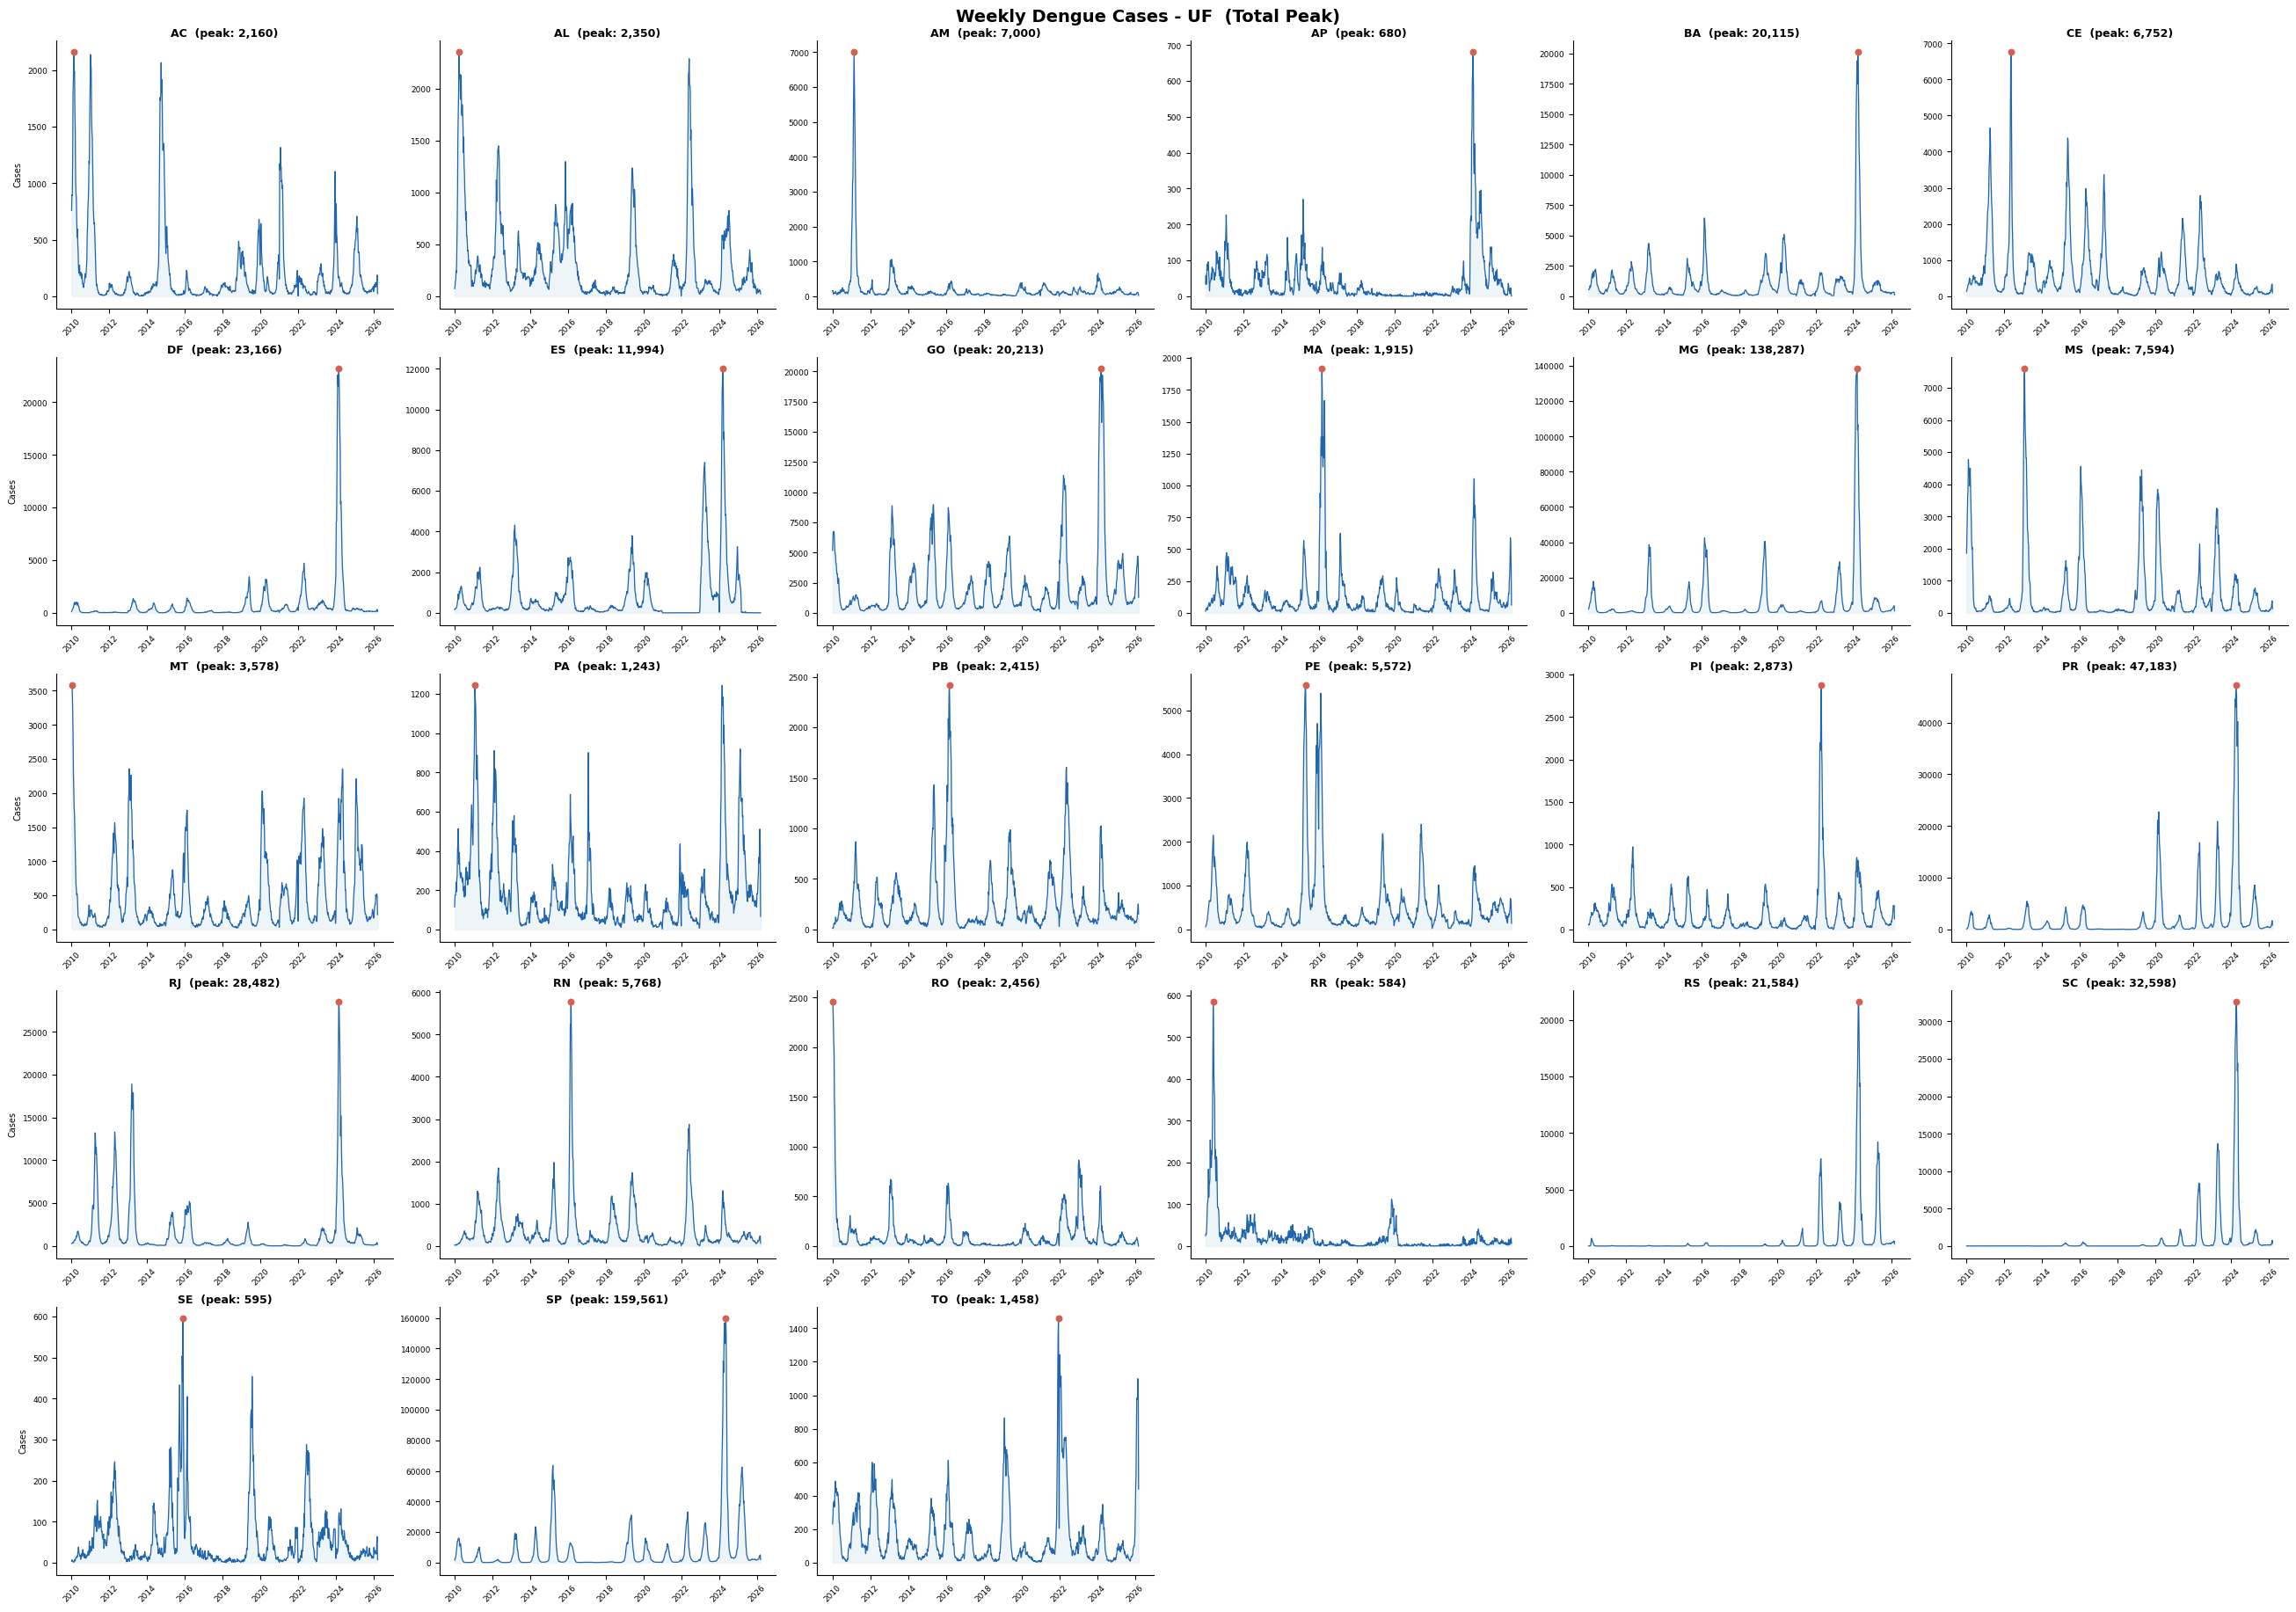

In [18]:
"""
===============
Mosaico de séries temporais de casos de dengue por UF.
"""
# Agrega casos semanais somando todos os municípios da UF
ts = (
    fdb.groupby(["uf", "date"], sort=True)["casos"]
    .sum()
    .reset_index()
)

ufs = sorted(ts["uf"].unique())
n_ufs = len(ufs)
print(f"  {n_ufs} UFs encontradas: {ufs}")

# ---------------------------------------------------------------------------
# Layout do mosaico  →  6 colunas x 5 linhas  (30 células, 27 UFs)
# ---------------------------------------------------------------------------
N_COLS = 6
N_ROWS = 5   # ceil(27 / 6) = 5

fig, axes = plt.subplots(
    N_ROWS, N_COLS,
    figsize=(26, 18),
    constrained_layout=True,
)
axes_flat = axes.flatten()

# Paleta: escala de azul→vermelho para destacar picos
COLOR_LINE  = "#2166ac"
COLOR_FILL  = "#d1e5f0"
COLOR_PEAK  = "#d6604d"

for i, uf in enumerate(ufs):
    ax = axes_flat[i]
    data = ts[ts["uf"] == uf].sort_values("date")

    ax.fill_between(data["date"], data["casos"], alpha=0.35, color=COLOR_FILL)
    ax.plot(data["date"], data["casos"], lw=0.9, color=COLOR_LINE)

    # Marca o pico
    idx_max = data["casos"].idxmax()
    ax.scatter(
        data.loc[idx_max, "date"], data.loc[idx_max, "casos"],
        color=COLOR_PEAK, s=22, zorder=5,
    )

    # Título com UF e valor do pico
    peak_val = int(data["casos"].max())
    ax.set_title(f"{uf}  (peak: {peak_val:,})", fontsize=9, fontweight="bold", pad=3)

    # Eixo X: apenas anos, fonte pequena
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", labelsize=6.5, rotation=45)
    ax.tick_params(axis="y", labelsize=6.5)

    # Remove bordas laterais para visual mais limpo
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlabel("")
    ax.set_ylabel("Cases" if i % N_COLS == 0 else "", fontsize=7)

# Oculta células vazias (30 - 27 = 3 sobram)
for j in range(n_ufs, len(axes_flat)):
    axes_flat[j].set_visible(False)

# Título geral
fig.suptitle(
    "Weekly Dengue Cases - UF  (Total Peak)",
    fontsize=14, fontweight="bold", y=1.01,
)

# ---------------------------------------------------------------------------
# Salva
# ---------------------------------------------------------------------------
#out_path = BASE_DIR / "ts_mosaic_uf.png"
#fig.savefig(out_path, dpi=150, bbox_inches="tight")
#print(f"  Figura salva em: {out_path}")
plt.show()

### 4. Correlation Analysis

Colunas contínuas para correlação:
  ['regional_geocode', 'population', 'regional_health_area_km2', 'temp_med', 'precip_med', 'pressure_med', 'rel_humid_med', 'thermal_range', 'rainy_days', 'enso', 'pop_density_km2']

Dummies separados em heatmap próprio:
  ['Af_koppen', 'Am_koppen', 'As_koppen', 'Aw_koppen', 'BSh_koppen', 'Cfa_koppen', 'Cfb_koppen', 'Cwa_koppen', 'Cwb_koppen', 'Amazônia_biome', 'Caatinga_biome', 'Cerrado_biome', 'Mata Atlântica_biome', 'Pampa_biome', 'Pantanal_biome']



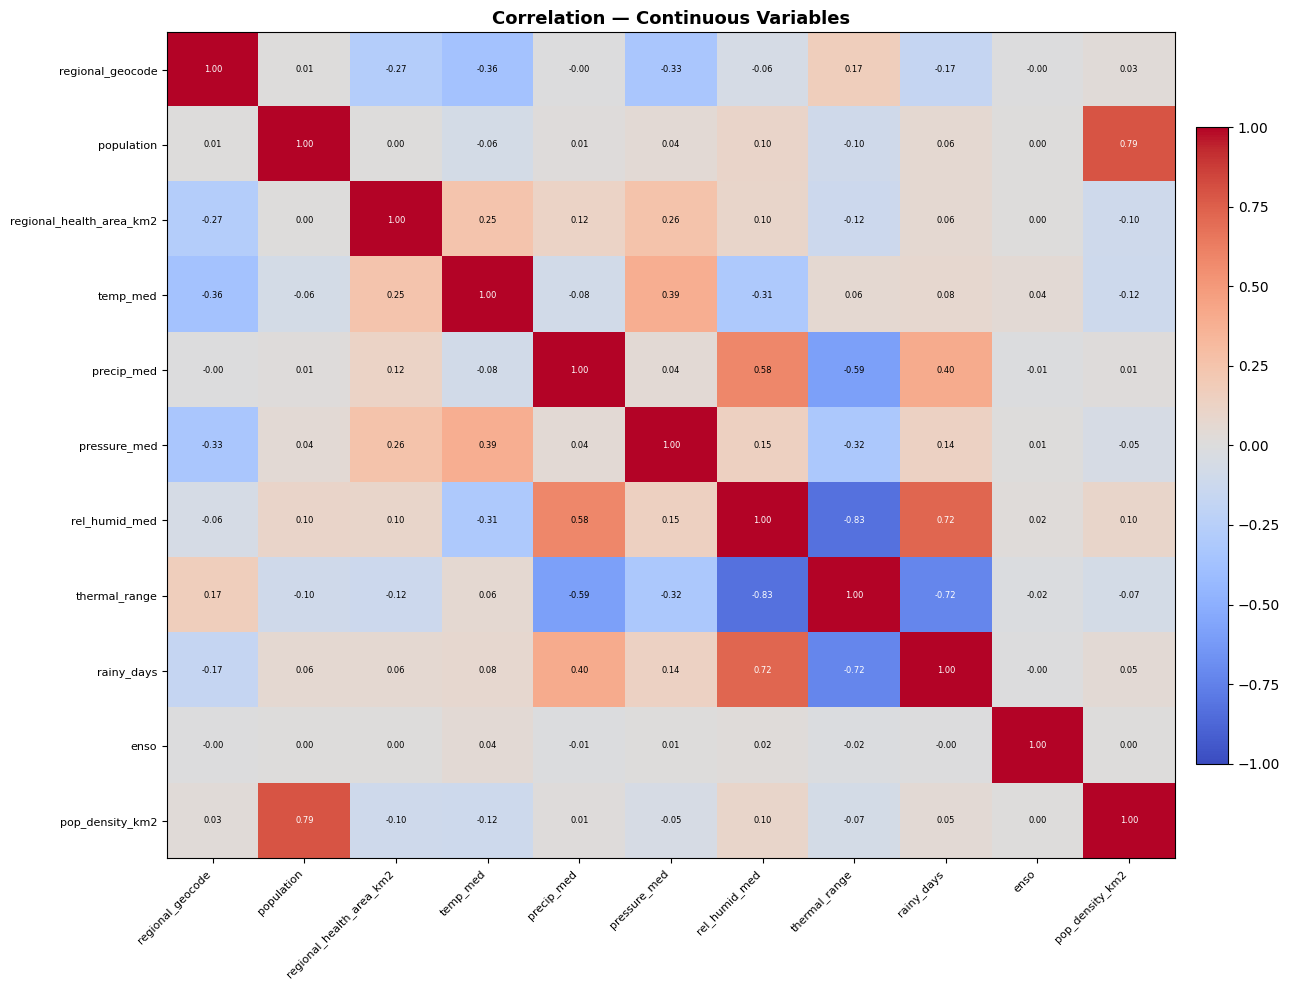

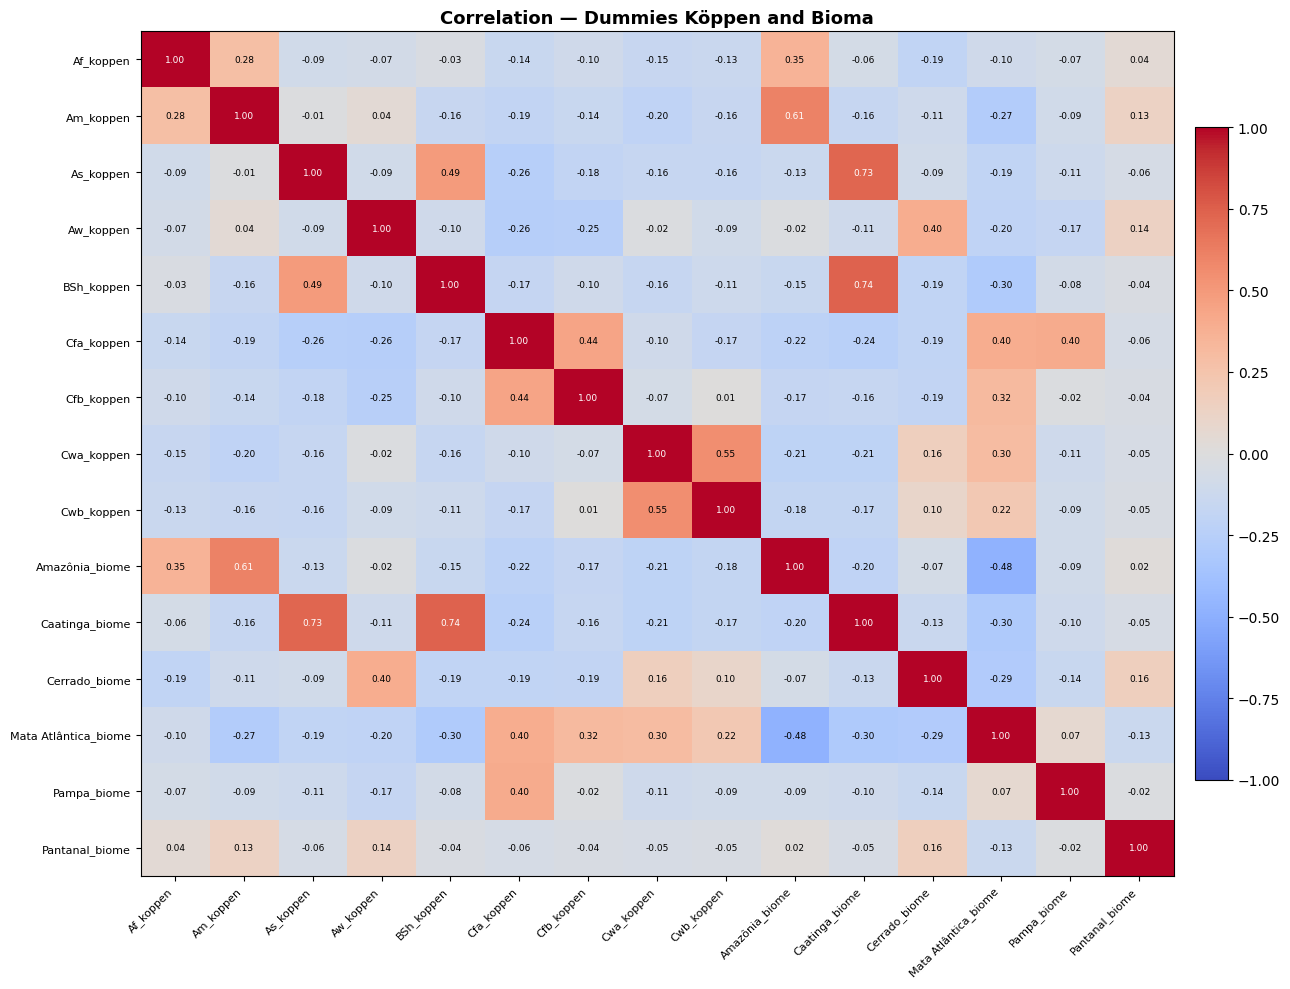

Correlation of each variable with 'casos'
                                 r          força
population                0.194863  low (0.1–0.3)
pop_density_km2           0.147094  low (0.1–0.3)
pressure_med             -0.046629    weak (<0.1)
regional_geocode          0.043789    weak (<0.1)
Mata Atlântica_biome      0.043732    weak (<0.1)
Amazônia_biome           -0.039506    weak (<0.1)
rel_humid_med             0.037855    weak (<0.1)
As_koppen                -0.035959    weak (<0.1)
enso                      0.033795    weak (<0.1)
Caatinga_biome           -0.033417    weak (<0.1)
thermal_range            -0.030944    weak (<0.1)
Cfb_koppen                0.026598    weak (<0.1)
Cwa_koppen                0.026540    weak (<0.1)
Cerrado_biome             0.024309    weak (<0.1)
Cfa_koppen                0.024182    weak (<0.1)
regional_health_area_km2 -0.022452    weak (<0.1)
BSh_koppen               -0.021649    weak (<0.1)
Cwb_koppen                0.020547    weak (<0.1)
Pampa_bi

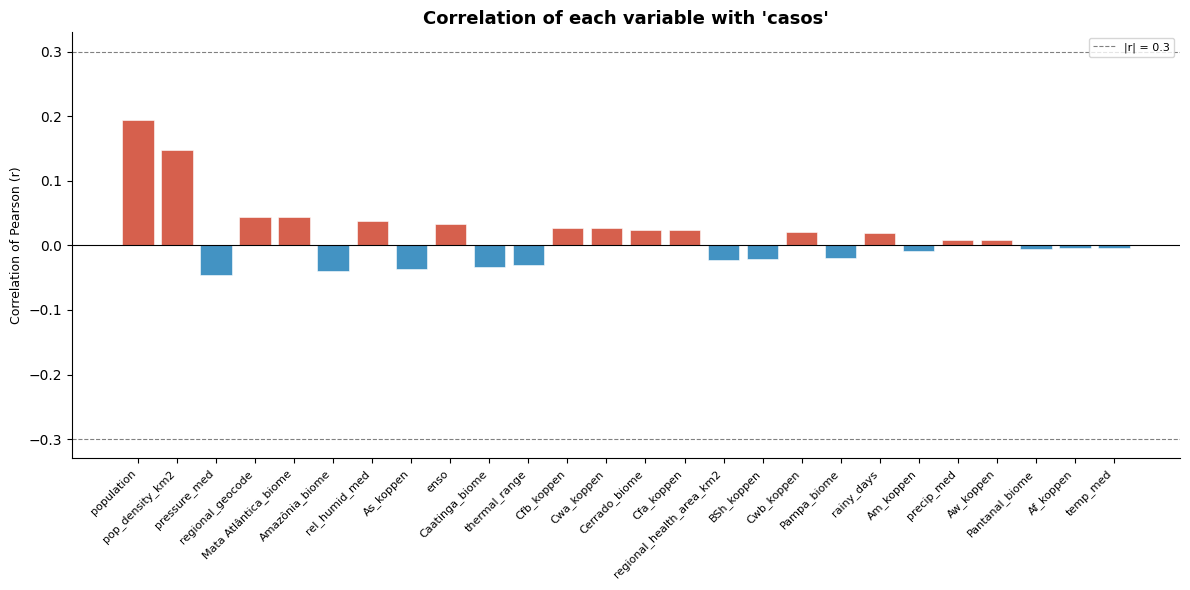


✓ Análise de correlação concluída.


In [3]:
"""
========================
Análise de correlação entre variáveis e autocorrelação de 'casos'.
"""

TARGET_COL = "casos"

# ---------------------------------------------------------------------------
# Seleção de colunas numéricas para correlação
#
# Estratégia:
#   • Variáveis contínuas/climáticas → heatmap principal
#   • Dummies (koppen + biome)       → heatmap separado (são 0/1)
#   • Excluídas: geocode, uf_code, year, epiweek (identificadores)
#     e colunas de flag train_*/target_* (booleanos de partição)
# ---------------------------------------------------------------------------
EXCLUIR = {"uf_code", "year", "epiweek", "macroregion_code",
    "train_1","train_2","train_3","train_4",
    "target_1","target_2","target_3","target_4",
}

koppen_cols = [c for c in fdb.columns if c.endswith("_koppen")]
biome_cols  = [c for c in fdb.columns if c.endswith("_biome")]
dummy_cols  = koppen_cols + biome_cols

# Contínuas: numéricas, não excluídas, não dummies
all_num = fdb.select_dtypes(include=np.number).columns.tolist()
cont_cols = [c for c in all_num if c not in EXCLUIR and c not in dummy_cols]
cont_cols = [c for c in cont_cols if c != TARGET_COL]

print("Colunas contínuas para correlação:")
print(f"  {cont_cols}\n")
print("Dummies separados em heatmap próprio:")
print(f"  {dummy_cols}\n")

# ---------------------------------------------------------------------------
# ATENÇÃO — dado em painel (semana × município)
# A correlação crua mistura variação temporal e cross-sectional.
# Optamos por manter o painel completo (mais observações, mais potência),
# mas documentamos a ressalva. Se quiser por UF, basta filtrar antes.
# ---------------------------------------------------------------------------

# --- CORREÇÃO 2: conversão para float64 puro (sem nullable) ---
raw_data = fdb[cont_cols + dummy_cols + [TARGET_COL]].copy()
raw_data = raw_data.astype(float)

# ---------------------------------------------------------------------------
# 1. HEATMAP — variáveis contínuas
# ---------------------------------------------------------------------------
corr_cont = raw_data[cont_cols].corr()

fig1, ax1 = plt.subplots(figsize=(13, 10))
im1 = ax1.imshow(corr_cont, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im1, ax=ax1, fraction=0.03, pad=0.02)

n = len(cont_cols)
ax1.set_xticks(range(n)); ax1.set_yticks(range(n))
ax1.set_xticklabels(cont_cols, rotation=45, ha="right", fontsize=8)
ax1.set_yticklabels(cont_cols, fontsize=8)

for i in range(n):
    for j in range(n):
        val = corr_cont.iloc[i, j]
        color = "white" if abs(val) > 0.6 else "black"
        ax1.text(j, i, f"{val:.2f}", ha="center", va="center",
                 fontsize=6, color=color)

ax1.set_title("Correlation — Continuous Variables", fontsize=13, fontweight="bold")
plt.tight_layout()
#fig1.savefig(BASE_DIR / "corr_continuas.png", dpi=150, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------------------------
# 2. HEATMAP — dummies (Köppen + Bioma)
# ---------------------------------------------------------------------------
corr_dum = raw_data[dummy_cols].corr()

fig2, ax2 = plt.subplots(figsize=(13, 10))
im2 = ax2.imshow(corr_dum, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im2, ax=ax2, fraction=0.03, pad=0.02)

nd = len(dummy_cols)
ax2.set_xticks(range(nd)); ax2.set_yticks(range(nd))
ax2.set_xticklabels(dummy_cols, rotation=45, ha="right", fontsize=8)
ax2.set_yticklabels(dummy_cols, fontsize=8)

for i in range(nd):
    for j in range(nd):
        val = corr_dum.iloc[i, j]
        color = "white" if abs(val) > 0.6 else "black"
        ax2.text(j, i, f"{val:.2f}", ha="center", va="center",
                 fontsize=6.5, color=color)

ax2.set_title("Correlation — Dummies Köppen and Bioma", fontsize=13, fontweight="bold")
plt.tight_layout()
#fig2.savefig(BASE_DIR / "corr_dummies.png", dpi=150, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------------------------
# 3. Correlação de cada variável com TARGET_COL ('casos')
#    Ordenada por |r| decrescente para facilitar triagem
# ---------------------------------------------------------------------------
print("=" * 55)
print(f"Correlation of each variable with '{TARGET_COL}'")
print("=" * 55)

target_corr = (
    raw_data[cont_cols + dummy_cols]
    .corrwith(raw_data[TARGET_COL])
    .rename("r")
    .to_frame()
)
target_corr["abs_r"] = target_corr["r"].abs()
target_corr = target_corr.sort_values("abs_r", ascending=False).drop(columns="abs_r")

# Referência: |r| > 0.3 = correlação moderada/forte com o target
target_corr["força"] = pd.cut(
    target_corr["r"].abs(),
    bins=[0, 0.1, 0.3, 0.5, 1.0],
    labels=["weak (<0.1)", "low (0.1–0.3)", "moderate (0.3–0.5)", "high (>0.5)"],
)
print(target_corr.to_string())

# ---------------------------------------------------------------------------
# 4. Pares de alta correlação entre variáveis (|r| ≥ 0.85)
#    Candidatos à remoção por redundância
# ---------------------------------------------------------------------------
print("\n" + "=" * 55)
print("Pairs with |r| ≥ 0.7  — removal candidates")
print("=" * 55)

# Bloco 4 — substituir as duas primeiras linhas por:
cols_para_corr = list(dict.fromkeys(cont_cols + dummy_cols))  # remove duplicatas mantendo ordem
cols_para_corr = [c for c in cols_para_corr if c != TARGET_COL]  # garante que target sai

corr_all = raw_data[cols_para_corr].corr().abs()
upper = corr_all.where(np.triu(np.ones(corr_all.shape), k=1).astype(bool))

high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "var_A", "level_1": "var_B", 0: "|r|"})
    .query("`|r|` >= 0.7")
    .sort_values("|r|", ascending=False)
)

if high_corr_pairs.empty:
    print("  No pair with |r| ≥ 0.85 founded.")
else:
    print(high_corr_pairs.to_string(index=False))

# ---------------------------------------------------------------------------
# 5. Autocorrelação de 'casos' com suas defasagens
#    Agregado nacional (soma de municípios por semana)
#    para eliminar ruído cross-sectional
# ---------------------------------------------------------------------------
print("\n" + "=" * 55)
print(f"Autocorrelation of '{TARGET_COL}' — national serie aggregated")
print("(lags in weeks)")
print("=" * 55)

serie_nacional = (
    fdb.groupby("date")[TARGET_COL]
    .sum()
    .sort_index()
    .astype(float)
)

lags = [1, 2, 3, 4, 6, 8, 12, 24, 36, 52, 72, 89, 120]
print(f"  {'lag (weeks)':>15}  {'r':>8}  {'interpretação'}")
print("  " + "-" * 45)
for lag in lags:
    r = serie_nacional.corr(serie_nacional.shift(lag))
    if abs(r) >= 0.7:
        interp = "forte ↑"
    elif abs(r) >= 0.4:
        interp = "moderada"
    else:
        interp = "fraca ↓"
    print(f"  {lag:>15}  {r:>+8.4f}  {interp}")

# ---------------------------------------------------------------------------
# 6. Gráfico de barras — correlação com o target
# ---------------------------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=(12, 6))
colors = ["#d6604d" if v >= 0 else "#4393c3" for v in target_corr["r"]]
ax3.bar(range(len(target_corr)), target_corr["r"], color=colors,  # <- usar range() no eixo X
        edgecolor="white", linewidth=0.4)
ax3.axhline(0,    color="black", linewidth=0.8)
ax3.axhline( 0.3, color="gray",  linewidth=0.8, linestyle="--", label="|r| = 0.3")
ax3.axhline(-0.3, color="gray",  linewidth=0.8, linestyle="--")
ax3.set_xticks(range(len(target_corr)))                           # <- adicionar esta linha
ax3.set_xticklabels(target_corr.index, rotation=45, ha="right", fontsize=8)
ax3.set_ylabel("Correlation of Pearson (r)", fontsize=9)
ax3.set_title(f"Correlation of each variable with '{TARGET_COL}'", fontsize=13, fontweight="bold")
ax3.legend(fontsize=8)
ax3.spines[["top","right"]].set_visible(False)
plt.tight_layout()
#fig3.savefig(BASE_DIR / "corr_com_target.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n✓ Análise de correlação concluída.")